# Conditional Workflow
- Based on a condition a particular node will be triggered
- The problem statement will resolve around solving the quadratic equations
- WKT discriminant $d = b^2 - 4ac$
- If d> 0 then 2 real roots i.e. $\frac{-b + \sqrt{d}}{2a}$ and $\frac{-b - \sqrt{d}}{2a}$
- If d = 0 1 repeated root i.e. $\frac{-b}{2a}$
- If d<0 then no root
- Workflow
    - START -> show_equation -> calculate_discriminant -> (no_real_roots, real_roots, repeated_roots) -> END
    - From calculate_discriminant we can go to either one of these nodes (no_real_roots, real_roots, repeated_roots), as its conditional



In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal


In [2]:
class State(TypedDict):
    a: int
    b: int
    c: int
    equation: str
    discriminant: float
    result: str

# Defining the functions

In [3]:
def show_equation(state: State): 
    equation = f"{state["a"]}x^2+{state["b"]}x+{state["c"]}"
    return {"equation": equation}

def compute_discriminant(state: State):
    discriminant = state["b"]**2 - (4*state["a"]*state["c"])

    return {"discriminant": discriminant}


def real_roots(state: State):
    root1 = (-state["b"]+state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"]-state["discriminant"]**0.5)/(2*state["a"])

    result = f"The roots are {root1} and {root2}"
    return {"result": result}

def repeated_roots(state: State):
    root1 = (-state["b"])/(2*state["a"])
    
    result = f"The only repeating root is {root1}"
    return {"result": result}

def no_real_roots(state: State):
    result = f"No real roots"
    return {"result": result} 

# Defining the conditional function
- To create conditional nodes, a seperate function must be created
- The function must return the node it has to invoke

In [4]:
def check_condition(state: State) -> Literal["real_roots", "no_real_roots", "repeated_roots"]:
    if state["discriminant"] >0 :
        return "real_roots"
    elif state["discriminant"] == 0 :
        return "repeated_roots"
    else:
        return "no_real_roots"

# Creating the graph and adding nodes and creating conditional edges
- To add a conditional edge we must use `add_conditional_edges(Node where the condition must be applied, The function which checks and specifies which node to connect to)`
- And the

In [5]:
# Creating graph
graph = StateGraph(State) 

# Creating Nodes
graph.add_node("show_equation", show_equation)
graph.add_node("compute_discriminant", compute_discriminant)
graph.add_node("real_roots", real_roots)
graph.add_node("no_real_roots", no_real_roots)
graph.add_node("repeated_roots", repeated_roots)



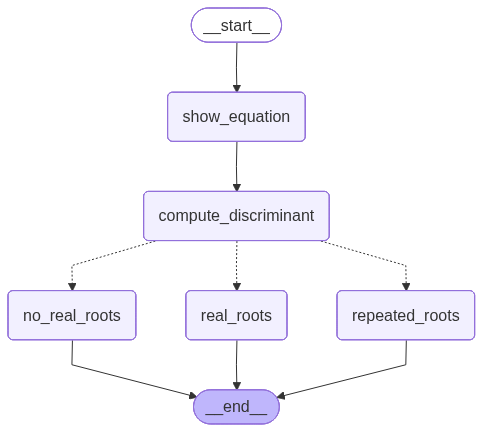

In [6]:

# Adding edges
graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "compute_discriminant")

# Adding conditional edge
graph.add_conditional_edges("compute_discriminant", check_condition)

# Adding edges from nodes that gets executed based on the condtion
graph.add_edge("real_roots", END)
graph.add_edge("no_real_roots", END)
graph.add_edge("repeated_roots", END)
graph.add_edge("compute_discriminant", END)

# Defining the workflow
workflow = graph.compile()
workflow

- Note the nodes that depends on the conditions have the dotted line in the diagram

In [7]:
initial_state = {"a": 4, "b":3, "c": 10}
workflow.invoke(initial_state)

{'a': 4,
 'b': 3,
 'c': 10,
 'equation': '4x^2+3x+10',
 'discriminant': -151,
 'result': 'No real roots'}